In [6]:
import wfdb
import os
import matplotlib.pyplot as plt
from src.preprocessing import build_dataset, RECORD_IDS
from src.dataset import build_dataloaders
from src.model import CNNLSTMClassifier
from src.train import train_model, evaluate_model

data_version = '1.0.0'
data_folder = f'data/physionet.org/files/mitdb/{data_version}'

In [5]:
X, y = build_dataset(data_folder, RECORD_IDS)

print(f'\nTotal: {X.shape[0]} batimentos, janela de {X.shape[1]} amostras')
print('Distribuição de classes:')

from src.preprocessing import CLASS_TO_IDX
import numpy as np

for cls, idx in CLASS_TO_IDX.items():
    count = np.sum(y == idx)
    print(f'  {cls}: {count} ({100*count/len(y):.2f}%)')

os.makedirs('data/processed', exist_ok=True)

np.save('data/processed/X.npy', X)
np.save('data/processed/y.npy', y)

Registro 100: 2271 batimentos
Registro 101: 1864 batimentos
Registro 102: 2185 batimentos
Registro 103: 2083 batimentos
Registro 104: 2227 batimentos
Registro 105: 2572 batimentos
Registro 106: 2027 batimentos
Registro 107: 2136 batimentos
Registro 108: 1762 batimentos
Registro 109: 2530 batimentos
Registro 111: 2124 batimentos
Registro 112: 2537 batimentos
Registro 113: 1793 batimentos
Registro 114: 1879 batimentos
Registro 115: 1951 batimentos
Registro 116: 2411 batimentos
Registro 117: 1534 batimentos
Registro 118: 2277 batimentos
Registro 119: 1987 batimentos
Registro 121: 1861 batimentos
Registro 122: 2474 batimentos
Registro 123: 1517 batimentos
Registro 124: 1618 batimentos
Registro 200: 2600 batimentos
Registro 201: 1962 batimentos
Registro 202: 2135 batimentos
Registro 203: 2979 batimentos
Registro 205: 2655 batimentos
Registro 207: 1859 batimentos
Registro 208: 2953 batimentos
Registro 209: 3004 batimentos
Registro 210: 2648 batimentos
Registro 212: 2747 batimentos
Registro 2

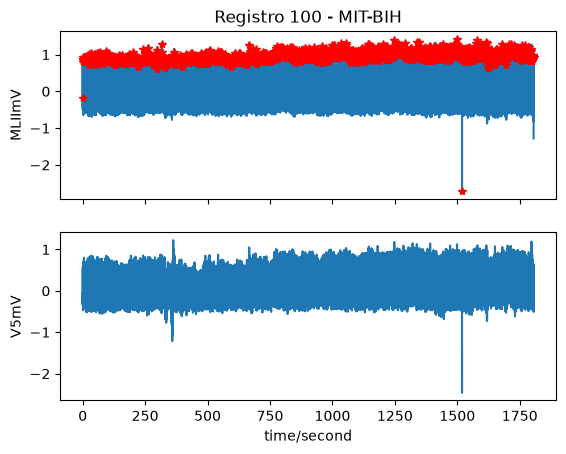

In [9]:
record = wfdb.rdrecord(f'{data_folder}/100')
annotation = wfdb.rdann(f'{data_folder}/100', 'atr')

wfdb.plot_wfdb(record=record, annotation=annotation, title='Registro 100 - MIT-BIH', time_units='seconds')

In [8]:
train_loader, val_loader, test_loader, class_weights = build_dataloaders(X, y, batch_size=128)

model = CNNLSTMClassifier(n_classes=5)

model = train_model(
    model, train_loader, val_loader, class_weights,
    n_epochs=30, patience=5,
    checkpoint_path='models/best_model.pt'
)

evaluate_model(model, test_loader)

Treino: 76606 | Validação: 16416 | Teste: 16416
Pesos de classe (N,S,V,F,Q): [0.2416326254606247, 7.869132041931152, 3.0255134105682373, 27.310516357421875, 2.7228007316589355]
Usando device: cpu
Época 01 | train_loss: 0.5512 | val_loss: 0.3442 | val_f1_macro: 0.6392
  -> novo melhor modelo salvo (val_f1_macro: 0.6392)
Época 02 | train_loss: 0.3107 | val_loss: 0.2811 | val_f1_macro: 0.6903
  -> novo melhor modelo salvo (val_f1_macro: 0.6903)
Época 03 | train_loss: 0.2346 | val_loss: 0.2779 | val_f1_macro: 0.7183
  -> novo melhor modelo salvo (val_f1_macro: 0.7183)
Época 04 | train_loss: 0.2154 | val_loss: 0.2695 | val_f1_macro: 0.7105
Época 05 | train_loss: 0.1961 | val_loss: 0.2651 | val_f1_macro: 0.7463
  -> novo melhor modelo salvo (val_f1_macro: 0.7463)
Época 06 | train_loss: 0.1681 | val_loss: 0.2248 | val_f1_macro: 0.7832
  -> novo melhor modelo salvo (val_f1_macro: 0.7832)
Época 07 | train_loss: 0.1480 | val_loss: 0.2489 | val_f1_macro: 0.7476
Época 08 | train_loss: 0.1443 | val

([np.int64(4),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(4),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(2),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(4),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(4),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(4),
  np.int64(0),
  np.int64(2),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(2),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64